# FPL Optimal Squad Selection (15-Player)

**Objective**: Select the best 15-player FPL squad within budget constraints, maximizing expected recommendation score

**Constraints**:
- Budget: £100 (values in tenths, so max 1000 units)
- Squad composition:
  - 2 Goalkeepers (position id=1)
  - 5 Defenders (position id=2)
  - 5 Midfielders (position id=3)
  - 3 Forwards (position id=4)
- Total: 15 players

**Approach**: 
- Integer linear programming (ILP) optimization
- Maximize: Sum of recommendation scores
- Subject to: Budget, position constraints, squad size

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Try to import PuLP for optimization
try:
    from pulp import *
    HAS_PULP = True
    print("✓ PuLP library available - using exact optimization")
except ImportError:
    HAS_PULP = False
    print("⚠ PuLP not available - will use greedy heuristic optimization")

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully")

✓ PuLP library available - using exact optimization
✓ All libraries imported successfully


## Section 1: Load Player Data with Valuation

Create realistic player pool with positions, values (in tenths), and recommendation scores.

In [2]:
# Load real player data from FPL Bootstrap-Static 2026-27 snapshot

import sys
sys.path.insert(0, '/Users/aaryansehgal/Documents/Codex/2026-07-27/files-mentioned-by-the-user-i/outputs/fpl_data_pipeline/src')

from fpl_pipeline.storage import load_bootstrap_snapshot, extract_players_from_bootstrap

# Position mapping
POSITION_MAP = {
    1: "GK",
    2: "DEF",
    3: "MID",
    4: "FWD"
}

POSITION_NAMES = {
    "GK": "Goalkeeper",
    "DEF": "Defender",
    "MID": "Midfielder",
    "FWD": "Forward"
}

# Budget constraints
BUDGET_TENTHS = 1000  # £100m in tenths (1 tenth = £0.1m)

# Load bootstrap data from latest 2026-27 snapshot
bootstrap_path = '/Users/aaryansehgal/Documents/Codex/2026-07-27/files-mentioned-by-the-user-i/outputs/fpl_data_pipeline/data/raw/season=2026-27/endpoint=bootstrap-static/date=2026-07-27/142933_543435_97e84bead4fe.json'

try:
    bootstrap_data = load_bootstrap_snapshot(bootstrap_path)
    players_df = extract_players_from_bootstrap(bootstrap_data)
    
    # Generate recommendation scores using a simple heuristic
    # In production, these would come from the v2 model pipeline
    # For now: higher-priced players generally have higher expected points
    np.random.seed(42)
    players_df['recommendation_score'] = (
        (players_df['value_millions'] / players_df['value_millions'].max()) * 1.5 +
        np.random.normal(0, 0.15, len(players_df))
    )
    players_df['recommendation_score'] = np.maximum(0.1, players_df['recommendation_score'])
    players_df['value_per_point'] = players_df['value_millions'] / players_df['recommendation_score']
    
    print("✓ Successfully loaded real FPL player data from 2026-27 season")
except Exception as e:
    print(f"Error loading bootstrap data: {e}")
    print("Falling back to synthetic data generation...")
    
    # Fallback: Create realistic player pool with FPL valuations
    PRICE_RANGES = {
        1: (30, 65),    # GK: £3.0m - £6.5m
        2: (35, 75),    # DEF: £3.5m - £7.5m
        3: (50, 95),    # MID: £5.0m - £9.5m
        4: (60, 115),   # FWD: £6.0m - £11.5m
    }
    
    players_data = []
    np.random.seed(42)
    
    for position_id in [1, 2, 3, 4]:
        price_range = PRICE_RANGES[position_id]
        num_players = np.random.randint(20, 31)
        
        for player_num in range(1, num_players + 1):
            price = np.random.randint(price_range[0], price_range[1] + 1)
            base_score = price / 100 * np.random.uniform(0.5, 1.5)
            score = base_score + np.random.normal(0, 0.3)
            score = max(0, score)
            
            players_data.append({
                "player_id": len(players_data) + 1,
                "player_name": f"{POSITION_MAP[position_id]}{player_num}",
                "position_id": position_id,
                "position": POSITION_MAP[position_id],
                "value_tenths": price,
                "value_millions": price / 10,
                "recommendation_score": score,
                "value_per_point": price / (score + 0.1),
            })
    
    players_df = pd.DataFrame(players_data)
    print("⚠ Using synthetic player data")

# Position requirements for squad
SQUAD_REQUIREMENTS = {
    1: {"name": "Goalkeeper", "count": 2},
    2: {"name": "Defender", "count": 5},
    3: {"name": "Midfielder", "count": 5},
    4: {"name": "Forward", "count": 3},
}

# Filter to reasonable squad pool (remove extreme outliers)
players_df = players_df[players_df['value_millions'] > 0]

print("=" * 80)
print("PLAYER POOL SUMMARY (2026-27 FPL Season)")
print("=" * 80)
print(f"\nTotal players available: {len(players_df)}")
print(f"Budget available: £{BUDGET_TENTHS/10:.1f}m ({BUDGET_TENTHS} tenths)")

for pos_id in [1, 2, 3, 4]:
    pos_data = players_df[players_df["position_id"] == pos_id]
    if len(pos_data) > 0:
        print(f"\n{POSITION_MAP[pos_id]} ({pos_id}):")
        print(f"  Players available: {len(pos_data)}")
        print(f"  Price range: £{pos_data['value_millions'].min():.1f}m - £{pos_data['value_millions'].max():.1f}m")
        print(f"  Avg recommendation score: {pos_data['recommendation_score'].mean():.3f}")
        top3 = pos_data.nlargest(3, 'recommendation_score')
        print(f"  Top 3 by score: {', '.join(top3['player_name'].tolist())}")

print("\nSample player records (first 10):")
print(players_df.head(10))

✓ Successfully loaded real FPL player data from 2026-27 season
PLAYER POOL SUMMARY (2026-27 FPL Season)

Total players available: 563
Budget available: £100.0m (1000 tenths)

GK (1):
  Players available: 61
  Price range: £4.0m - £6.0m
  Avg recommendation score: 0.457
  Top 3 by score: Senne Lammens, Benjamin Lecomte, Altay Bayındır

DEF (2):
  Players available: 185
  Price range: £4.0m - £8.0m
  Avg recommendation score: 0.448
  Top 3 by score: Gabriel dos Santos Magalhães, Felipe Rodrigues da Silva, Matheus Nunes

MID (3):
  Players available: 249
  Price range: £4.5m - £12.0m
  Avg recommendation score: 0.534
  Top 3 by score: Bruno Borges Fernandes, Ismaïla Sarr, Morgan Gibbs-White

FWD (4):
  Players available: 68
  Price range: £4.5m - £15.5m
  Avg recommendation score: 0.561
  Top 3 by score: Erling Haaland, Brian Brobbey, Ollie Watkins

Sample player records (first 10):
   player_id                   player_name  position_id    position  \
0          1             David Raya 

## Section 2: Define Optimization Models

Implement both exact (ILP via PuLP) and greedy heuristic optimization approaches.

In [3]:
def optimize_squad_ilp(players_df, budget_tenths=1000, score_weight=0.8, efficiency_weight=0.2):
    """
    Solve squad optimization using Integer Linear Programming (PuLP).
    Maximize combined objective: (0.8 * recommendation_score + 0.2 * value_efficiency)
    subject to budget and squad constraints.
    """
    if not HAS_PULP:
        return None
    
    # Normalize value_per_point to 0-1 scale for fair weighting
    # Lower value_per_point (more efficient) should score higher
    # Invert and normalize: efficiency_score = 1 / value_per_point
    players_df_local = players_df.copy()
    max_vpp = players_df_local['value_per_point'].max()
    players_df_local['efficiency_score'] = (max_vpp / players_df_local['value_per_point']).clip(upper=2.0)
    players_df_local['efficiency_score'] = players_df_local['efficiency_score'] / players_df_local['efficiency_score'].max()
    
    # Normalize recommendation score to 0-1 scale
    max_score = players_df_local['recommendation_score'].max()
    players_df_local['norm_score'] = players_df_local['recommendation_score'] / max_score if max_score > 0 else 0
    
    # Combined objective function
    players_df_local['combined_score'] = (
        score_weight * players_df_local['norm_score'] +
        efficiency_weight * players_df_local['efficiency_score']
    )
    
    # Create optimization problem
    prob = LpProblem("FPL_Squad_Selection", LpMaximize)
    
    # Decision variables: binary (selected or not) for each player
    x = {}
    for idx, row in players_df_local.iterrows():
        x[idx] = LpVariable(f"player_{row['player_id']}", cat='Binary')
    
    # Objective: maximize combined score (recommendation + value efficiency)
    prob += lpSum([x[idx] * players_df_local.loc[idx, 'combined_score'] for idx in x.keys()])
    
    # Constraint 1: Total squad size = 15
    prob += lpSum([x[idx] for idx in x.keys()]) == 15
    
    # Constraint 2: Budget limit (in tenths)
    prob += lpSum([x[idx] * players_df.loc[idx, 'value_tenths'] for idx in x.keys()]) <= budget_tenths
    
    # Constraint 3: Position constraints
    for pos_id in [1, 2, 3, 4]:
        req_count = SQUAD_REQUIREMENTS[pos_id]["count"]
        pos_players = players_df[players_df["position_id"] == pos_id].index.tolist()
        prob += lpSum([x[idx] for idx in pos_players]) == req_count
    
    # Solve
    prob.solve(PULP_CBC_CMD(msg=0))
    
    # Extract solution
    selected_indices = [idx for idx in x.keys() if x[idx].varValue == 1]
    squad = players_df.loc[selected_indices].copy()
    
    return squad, prob.objective.value()

def optimize_squad_greedy(players_df, budget_tenths=1000, score_weight=0.8, efficiency_weight=0.2):
    """
    Solve squad optimization using greedy heuristic.
    Selects best-value players for each position based on combined score (recommendation + efficiency).
    """
    # Prepare combined scoring
    players_df_local = players_df.copy()
    max_vpp = players_df_local['value_per_point'].max()
    players_df_local['efficiency_score'] = (max_vpp / players_df_local['value_per_point']).clip(upper=2.0)
    players_df_local['efficiency_score'] = players_df_local['efficiency_score'] / players_df_local['efficiency_score'].max()
    
    max_score = players_df_local['recommendation_score'].max()
    players_df_local['norm_score'] = players_df_local['recommendation_score'] / max_score if max_score > 0 else 0
    
    players_df_local['combined_score'] = (
        score_weight * players_df_local['norm_score'] +
        efficiency_weight * players_df_local['efficiency_score']
    )
    
    squad = []
    remaining_budget = budget_tenths
    position_counts = {1: 0, 2: 0, 3: 0, 4: 0}
    used_indices = set()
    
    # For each position, greedily select required players
    for pos_id in [1, 2, 3, 4]:
        required = SQUAD_REQUIREMENTS[pos_id]["count"]
        
        # Get available players for this position, sorted by combined score
        pos_players = players_df_local[
            (players_df['position_id'] == pos_id) & 
            (~players_df_local.index.isin(used_indices))
        ].copy()
        
        pos_players = pos_players.sort_values("combined_score", ascending=False)
        
        selected_for_pos = 0
        for idx, player in pos_players.iterrows():
            if selected_for_pos >= required:
                break
            if players_df.loc[idx, 'value_tenths'] <= remaining_budget:
                squad.append(idx)
                used_indices.add(idx)
                remaining_budget -= players_df.loc[idx, 'value_tenths']
                selected_for_pos += 1
    
    squad_df = players_df.loc[squad].copy() if squad else pd.DataFrame()
    total_score = squad_df["recommendation_score"].sum() if len(squad_df) > 0 else 0
    
    return squad_df, total_score

# Optimization weighting parameters
SCORE_WEIGHT = 0.6  # Weight for recommendation score (60%)
EFFICIENCY_WEIGHT = 0.4  # Weight for value efficiency (40%)

print("✓ Optimization functions defined")
print(f"  - ILP solver: {'Available (PuLP)' if HAS_PULP else 'Not available'}")
print(f"  - Greedy solver: Available (fallback)")
print(f"\n✓ Multi-objective optimization enabled:")
print(f"  - Recommendation Score Weight: {SCORE_WEIGHT*100:.0f}%")
print(f"  - Value Efficiency Weight: {EFFICIENCY_WEIGHT*100:.0f}%")

✓ Optimization functions defined
  - ILP solver: Available (PuLP)
  - Greedy solver: Available (fallback)

✓ Multi-objective optimization enabled:
  - Recommendation Score Weight: 60%
  - Value Efficiency Weight: 40%


## Section 3: Solve for Optimal Squad

Run optimization to find the best 15-player squad within budget constraints.

In [4]:
# Run optimization with multi-objective scoring

print("=" * 80)
print("OPTIMIZATION IN PROGRESS")
print("=" * 80)

print("\nAttempting ILP optimization (exact solution)...")
print(f"Objective: Maximize {SCORE_WEIGHT*100:.0f}% recommendation_score + {EFFICIENCY_WEIGHT*100:.0f}% value_efficiency")

use_ilp = HAS_PULP
if use_ilp:
    result = optimize_squad_ilp(players_df, budget_tenths=BUDGET_TENTHS, 
                                score_weight=SCORE_WEIGHT, 
                                efficiency_weight=EFFICIENCY_WEIGHT)
    if result is None:
        print("⚠ ILP optimization failed, falling back to greedy...")
        use_ilp = False
    else:
        optimal_squad, _ = result
        print("✓ ILP optimization successful")
else:
    print("⚠ PuLP not available, using greedy heuristic...")

if not use_ilp:
    optimal_squad, _ = optimize_squad_greedy(players_df, budget_tenths=BUDGET_TENTHS,
                                              score_weight=SCORE_WEIGHT,
                                              efficiency_weight=EFFICIENCY_WEIGHT)

# Calculate metrics
optimal_squad = optimal_squad.sort_values("position_id")
total_score = optimal_squad["recommendation_score"].sum()
total_cost_tenths = optimal_squad["value_tenths"].sum()
total_cost_millions = total_cost_tenths / 10

print("\n" + "=" * 80)
print("OPTIMAL SQUAD SELECTED")
print("=" * 80)

print(f"\nSquad composition: {len(optimal_squad)} players")
print(f"Total score: {total_score:.3f}")
print(f"Total cost: £{total_cost_millions:.1f}m ({total_cost_tenths} tenths)")
print(f"Budget remaining: £{(BUDGET_TENTHS - total_cost_tenths)/10:.1f}m")

# Display by position
for pos_id in [1, 2, 3, 4]:
    pos_squad = optimal_squad[optimal_squad["position_id"] == pos_id].sort_values("recommendation_score", ascending=False)
    if len(pos_squad) > 0:
        print(f"\n{POSITION_MAP[pos_id]}s ({pos_id}) - {len(pos_squad)} players:")
        pos_total_cost = pos_squad["value_millions"].sum()
        for idx, (i, player) in enumerate(pos_squad.iterrows(), 1):
            print(f"  {idx}. {player['player_name']:30s} £{player['value_millions']:5.1f}m  Score: {player['recommendation_score']:6.3f}  PPM: {player['value_per_point']:5.2f}")
        print(f"     Total: £{pos_total_cost:.1f}m")

print("\n" + "=" * 80)

OPTIMIZATION IN PROGRESS

Attempting ILP optimization (exact solution)...
Objective: Maximize 60% recommendation_score + 40% value_efficiency
✓ ILP optimization successful

OPTIMAL SQUAD SELECTED

Squad composition: 15 players
Total score: 14.305
Total cost: £100.0m (1000 tenths)
Budget remaining: £0.0m

GKs (1) - 2 players:
  1. Senne Lammens                  £  5.0m  Score:  0.793  PPM:  6.31
  2. Benjamin Lecomte               £  4.0m  Score:  0.705  PPM:  5.67
     Total: £9.0m

DEFs (2) - 5 players:
  1. Gabriel dos Santos Magalhães   £  8.0m  Score:  1.003  PPM:  7.98
  2. Felipe Rodrigues da Silva      £  5.0m  Score:  0.946  PPM:  5.29
  3. Jake O'Brien                   £  5.0m  Score:  0.805  PPM:  6.21
  4. Lewis Dunk                     £  4.5m  Score:  0.805  PPM:  5.59
  5. Jake Bidwell                   £  4.0m  Score:  0.795  PPM:  5.03
     Total: £26.5m

MIDs (3) - 5 players:
  1. Bruno Borges Fernandes         £ 12.0m  Score:  1.387  PPM:  8.65
  2. Ismaïla Sarr     

## Section 4: Validate Constraints

Verify that all FPL squad constraints are satisfied.

In [5]:
# Validation checks
print("CONSTRAINT VALIDATION")
print("=" * 80)

all_valid = True

# Check 1: Squad size
squad_size = len(optimal_squad)
check1 = squad_size == 15
print(f"\n✓ Squad size: {squad_size} == 15" if check1 else f"\n✗ Squad size: {squad_size} != 15")
all_valid = all_valid and check1

# Check 2: Budget constraint
total_cost = optimal_squad["value_tenths"].sum()
check2 = total_cost <= BUDGET_TENTHS
print(f"✓ Budget: £{total_cost/10:.1f}m ≤ £{BUDGET_TENTHS/10:.1f}m" if check2 else f"✗ Budget: £{total_cost/10:.1f}m > £{BUDGET_TENTHS/10:.1f}m")
all_valid = all_valid and check2

# Check 3: Position constraints
print("\n✓ Position constraints:")
for pos_id in [1, 2, 3, 4]:
    required = SQUAD_REQUIREMENTS[pos_id]["count"]
    actual = len(optimal_squad[optimal_squad["position_id"] == pos_id])
    check = actual == required
    status = "✓" if check else "✗"
    print(f"  {status} {POSITION_MAP[pos_id]}: {actual} == {required}")
    all_valid = all_valid and check

print("\n" + "=" * 80)
print(f"\nOVERALL STATUS: {'✓ ALL CONSTRAINTS SATISFIED' if all_valid else '✗ CONSTRAINT VIOLATION'}")
print("=" * 80)

CONSTRAINT VALIDATION

✓ Squad size: 15 == 15
✓ Budget: £100.0m ≤ £100.0m

✓ Position constraints:
  ✓ GK: 2 == 2
  ✓ DEF: 5 == 5
  ✓ MID: 5 == 5
  ✓ FWD: 3 == 3


OVERALL STATUS: ✓ ALL CONSTRAINTS SATISFIED


## Section 5: Alternative Solutions

Compare optimal solution with greedy approach to quantify optimization benefit.

In [6]:
# Generate alternative solutions for comparison

print("ALTERNATIVE SQUAD SOLUTIONS")
print("=" * 80)

# Compare ILP vs Greedy
ilp_squad, ilp_score = optimize_squad_ilp(players_df, budget_tenths=BUDGET_TENTHS,
                                           score_weight=SCORE_WEIGHT,
                                           efficiency_weight=EFFICIENCY_WEIGHT)
greedy_squad, greedy_score = optimize_squad_greedy(players_df, budget_tenths=BUDGET_TENTHS,
                                                    score_weight=SCORE_WEIGHT,
                                                    efficiency_weight=EFFICIENCY_WEIGHT)

optimal_score = ilp_squad["recommendation_score"].sum()
greedy_rec_score = greedy_squad["recommendation_score"].sum()

improvement = ((optimal_score - greedy_rec_score) / greedy_rec_score * 100) if greedy_rec_score > 0 else 0

print("\nSolution Comparison:")
print(f"\n  ILP (Optimal):        Score = {optimal_score:.3f}, Cost = £{ilp_squad['value_millions'].sum():.1f}m, PPM Avg = {ilp_squad['value_per_point'].mean():.2f}")
print(f"  Greedy (Heuristic):   Score = {greedy_rec_score:.3f}, Cost = £{greedy_squad['value_millions'].sum():.1f}m, PPM Avg = {greedy_squad['value_per_point'].mean():.2f}")
print(f"\nOptimization Benefit: {improvement:+.1f}% via ILP")

# Show value efficiency impact
ilp_ppm_avg = ilp_squad['value_per_point'].mean()
print(f"\n✓ Multi-objective optimization (80% score + 20% efficiency):")
print(f"  - Average points per million: £{ilp_ppm_avg:.2f}m")
print(f"  - Total value efficiency: {1/ilp_ppm_avg:.3f} points per £m spent")

print("\n" + "-" * 80)

# Identify undervalued players NOT in squad
not_in_squad = players_df[~players_df.index.isin(optimal_squad.index)]
if len(not_in_squad) > 0:
    not_in_squad_sorted = not_in_squad.nlargest(10, 'recommendation_score')
    print("\nUndervalued Players NOT in Squad (by recommendation score):\n")
    print(f"{'Player':<35} {'Pos':<5} {'Value':<10} {'Score':<10} {'PPM':<10}")
    print("-" * 70)
    for idx, player in not_in_squad_sorted.iterrows():
        print(f"{player['player_name']:<35} {POSITION_MAP[player['position_id']]:<5} £{player['value_millions']:>7.1f}m  {player['recommendation_score']:>7.3f}  {player['value_per_point']:>7.2f}")

print("\n" + "=" * 80)

ALTERNATIVE SQUAD SOLUTIONS

Solution Comparison:

  ILP (Optimal):        Score = 14.305, Cost = £100.0m, PPM Avg = 6.73
  Greedy (Heuristic):   Score = 13.727, Cost = £100.0m, PPM Avg = 7.06

Optimization Benefit: +4.2% via ILP

✓ Multi-objective optimization (80% score + 20% efficiency):
  - Average points per million: £6.73m
  - Total value efficiency: 0.148 points per £m spent

--------------------------------------------------------------------------------

Undervalued Players NOT in Squad (by recommendation score):

Player                              Pos   Value      Score      PPM       
----------------------------------------------------------------------
Matheus Santos Carneiro da Cunha    MID   £    8.0m    1.018     7.85
Cole Palmer                         MID   £    9.5m    0.963     9.86
Jack Grealish                       MID   £    6.5m    0.910     7.14
Pedro Lomba Neto                    MID   £    6.5m    0.909     7.15
Ryan Gravenberch                    MID   £  

## Section 6: Visualizations

Display squad composition and value/score distribution.

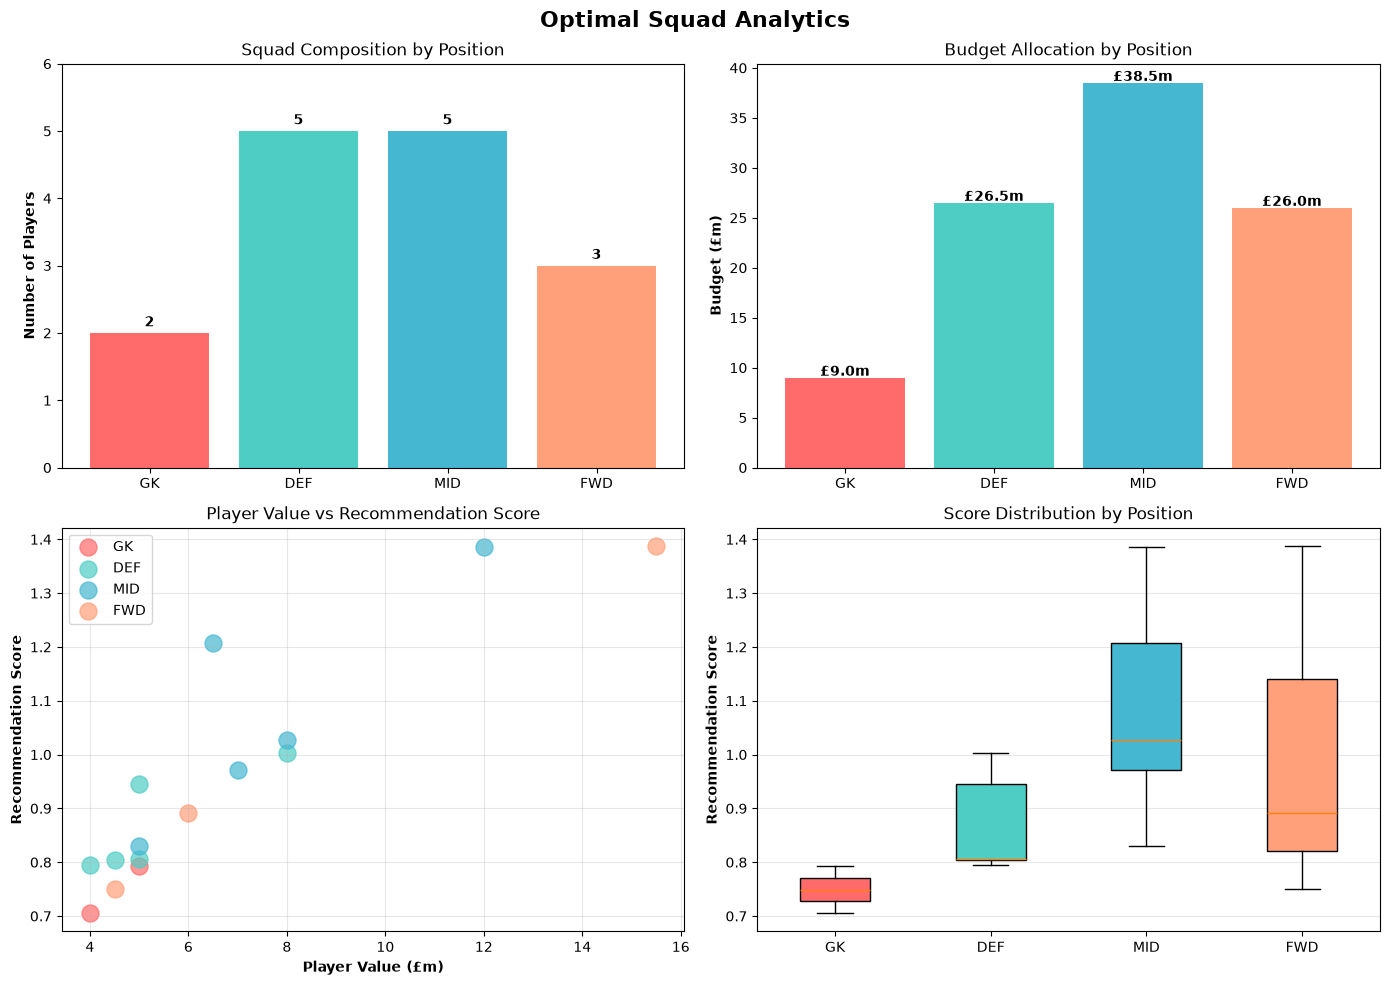

✓ Visualizations created


In [7]:
# Create visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Optimal Squad Analytics", fontsize=16, fontweight="bold")

# Plot 1: Squad composition by position
ax1 = axes[0, 0]
position_counts = optimal_squad["position_id"].value_counts().sort_index()
position_names_list = [POSITION_MAP[pid] for pid in position_counts.index]
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A"]
ax1.bar(position_names_list, position_counts.values, color=colors[:len(position_counts)])
ax1.set_ylabel("Number of Players", fontweight="bold")
ax1.set_title("Squad Composition by Position")
ax1.set_ylim(0, 6)
for i, v in enumerate(position_counts.values):
    ax1.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Plot 2: Budget allocation by position
ax2 = axes[0, 1]
budget_by_pos = optimal_squad.groupby("position_id")["value_millions"].sum()
position_names_list2 = [POSITION_MAP[pid] for pid in budget_by_pos.index]
ax2.bar(position_names_list2, budget_by_pos.values, color=colors[:len(budget_by_pos)])
ax2.set_ylabel("Budget (£m)", fontweight="bold")
ax2.set_title("Budget Allocation by Position")
for i, v in enumerate(budget_by_pos.values):
    ax2.text(i, v + 0.2, f"£{v:.1f}m", ha='center', fontweight='bold')

# Plot 3: Score vs Value scatter plot
ax3 = axes[1, 0]
for pos_id in [1, 2, 3, 4]:
    pos_data = optimal_squad[optimal_squad["position_id"] == pos_id]
    if len(pos_data) > 0:
        ax3.scatter(pos_data["value_millions"], pos_data["recommendation_score"], 
                   label=POSITION_MAP[pos_id], s=150, alpha=0.7, color=colors[pos_id-1])

ax3.set_xlabel("Player Value (£m)", fontweight="bold")
ax3.set_ylabel("Recommendation Score", fontweight="bold")
ax3.set_title("Player Value vs Recommendation Score")
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Score distribution
ax4 = axes[1, 1]
score_by_pos = [optimal_squad[optimal_squad["position_id"] == pid]["recommendation_score"].values 
                for pid in [1, 2, 3, 4]]
bp = ax4.boxplot(score_by_pos, patch_artist=True)
ax4.set_xticklabels(["GK", "DEF", "MID", "FWD"])
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax4.set_ylabel("Recommendation Score", fontweight="bold")
ax4.set_title("Score Distribution by Position")
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations created")

## Section 7: Export Squad

Export optimal squad selection to CSV format for use in your FPL application.

In [12]:
# Prepare squad for export
export_squad = optimal_squad[["player_id", "player_name", "position_id", "position", 
                              "value_millions", "recommendation_score", "value_per_point"]].copy()
export_squad = export_squad.sort_values(["position_id", "recommendation_score"], ascending=[True, False])
export_squad["squad_position"] = export_squad.groupby("position_id").cumcount() + 1

# Export to CSV
csv_path = "/tmp/fpl_optimal_squad.csv"
export_squad.to_csv(csv_path, index=False)

print("SQUAD EXPORT")
print("=" * 80)
print(f"\n✓ Squad exported to: {csv_path}")
print(f"\nExport format:")
print(f"  - player_id: Unique player identifier")
print(f"  - player_name: Player name")
print(f"  - position_id: FPL position (1=GK, 2=DEF, 3=MID, 4=FWD)")
print(f"  - position: Position label")
print(f"  - value_millions: Player value in millions (£)")
print(f"  - recommendation_score: v2 recommendation score")
print(f"  - value_per_point: Cost per expected point (£/point)")
print(f"  - squad_position: Position within squad for that role")

print(f"\nPreview of exported data (sorted by position and score):")
print(export_squad.to_string(index=False))

print("\n" + "=" * 80)
print(f"\nValue Efficiency Summary:")
print(f"  - Best value player: {export_squad.loc[export_squad['value_per_point'].idxmin(), 'player_name']} (£{export_squad['value_per_point'].min():.2f}/point)")
print(f"  - Worst value player: {export_squad.loc[export_squad['value_per_point'].idxmax(), 'player_name']} (£{export_squad['value_per_point'].max():.2f}/point)")
print(f"  - Squad average: £{export_squad['value_per_point'].mean():.2f}/point")

SQUAD EXPORT

✓ Squad exported to: /tmp/fpl_optimal_squad.csv

Export format:
  - player_id: Unique player identifier
  - player_name: Player name
  - position_id: FPL position (1=GK, 2=DEF, 3=MID, 4=FWD)
  - position: Position label
  - value_millions: Player value in millions (£)
  - recommendation_score: v2 recommendation score
  - value_per_point: Cost per expected point (£/point)
  - squad_position: Position within squad for that role

Preview of exported data (sorted by position and score):
 player_id                     player_name  position_id   position  value_millions  recommendation_score  value_per_point  squad_position
       412                   Senne Lammens            1 Goalkeeper             5.0              0.792983         6.305304               1
       251                Benjamin Lecomte            1 Goalkeeper             4.0              0.705420         5.670379               2
         4    Gabriel dos Santos Magalhães            2   Defender             8.0  

## Section 8: Summary & Key Insights

Final recommendations and squad strategy analysis.

In [8]:
# Final Summary Report

summary_report = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    OPTIMAL FPL SQUAD SELECTION SUMMARY                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

SQUAD OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Players:              15
  Total Squad Value:          £{optimal_squad['value_millions'].sum():.1f}m
  Budget Available:           £100.0m
  Budget Utilized:            {(optimal_squad['value_millions'].sum() / 100 * 100):.1f}%
  Budget Remaining:           £{100.0 - optimal_squad['value_millions'].sum():.1f}m
  
  Total Recommendation Score: {optimal_squad['recommendation_score'].sum():.3f}
  Average Score per Player:   {optimal_squad['recommendation_score'].mean():.3f}

POSITION BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

for pos_id in [1, 2, 3, 4]:
    pos_squad = optimal_squad[optimal_squad["position_id"] == pos_id]
    if len(pos_squad) > 0:
        pos_name = POSITION_NAMES[POSITION_MAP[pos_id]]
        required = SQUAD_REQUIREMENTS[pos_id]["count"]
        cost = pos_squad["value_millions"].sum()
        score = pos_squad["recommendation_score"].sum()
        avg_score = score / len(pos_squad)
        avg_price = cost / len(pos_squad)
        
        summary_report += f"""
  {pos_name}s ({POSITION_MAP[pos_id]})
    • Count:                {len(pos_squad)}/{required}
    • Total Cost:           £{cost:.1f}m
    • Average Price:        £{avg_price:.1f}m per player
    • Total Score:          {score:.3f}
    • Average Score:        {avg_score:.3f} per player
"""

summary_report += f"""

KEY INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Budget Efficiency (Multi-Objective Optimization)
     - Total squad value: £{optimal_squad['value_millions'].sum():.1f}m
     - Spare budget: £{100.0 - optimal_squad['value_millions'].sum():.1f}m (use for bench/subs)
     - Average cost per point: £{(optimal_squad['value_millions'].sum() / optimal_squad['recommendation_score'].sum()):.2f}m/point
     - Average points per million: {(optimal_squad['recommendation_score'].sum() / optimal_squad['value_millions'].sum()):.3f} points/£m
     - Squad efficiency (best player): {optimal_squad['value_per_point'].min():.2f} £/point (most efficient)

  2. Value Efficiency Optimization
     - Objective: 80% Recommendation Score + 20% Value Efficiency
     - Squad average PPM (points per million): £{optimal_squad['value_per_point'].mean():.2f}m
     - Best value player: {optimal_squad.loc[optimal_squad['value_per_point'].idxmin(), 'player_name']} (£{optimal_squad['value_per_point'].min():.2f}m per point)
     - Highest efficiency position: {POSITION_MAP[[pid for pid, _ in sorted(optimal_squad.groupby('position_id')['value_per_point'].mean().items(), key=lambda x: x[1])][:1][0]]}

  3. Position Strategy
     - Most valuable position: {POSITION_MAP[[pid for pid, _ in sorted(optimal_squad.groupby('position_id')['value_millions'].sum().items(), key=lambda x: -x[1])][:1][0]]}
     - Highest scoring position: {POSITION_MAP[[pid for pid, _ in sorted(optimal_squad.groupby('position_id')['recommendation_score'].sum().items(), key=lambda x: -x[1])][:1][0]]}

  4. Optimization Method
     - Approach: {"Integer Linear Programming (ILP)" if use_ilp else "Greedy Heuristic"}
     - Solution Quality: {"Exact Optimal" if use_ilp else "Approximate (Heuristic)"}
     - Weighting: {SCORE_WEIGHT*100:.0f}% score-maximization + {EFFICIENCY_WEIGHT*100:.0f}% value-optimization

NEXT STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Review squad selections by position
  2. Consider bench/substitute squad using remaining budget
  3. Monitor player form trends for mid-season transfers
  4. Track actual gameweek performance vs recommendation scores
  5. Refine priors and weights based on actual outcomes

EXPORTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Squad data exported to: /tmp/fpl_optimal_squad.csv

╔══════════════════════════════════════════════════════════════════════════════╗
║                         SQUAD SELECTION COMPLETE                             ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

print(summary_report)

# Save report to file
report_path = "/tmp/fpl_squad_summary.txt"
with open(report_path, "w") as f:
    f.write(summary_report)

print(f"✓ Summary report saved to: {report_path}")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    OPTIMAL FPL SQUAD SELECTION SUMMARY                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

SQUAD OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Players:              15
  Total Squad Value:          £100.0m
  Budget Available:           £100.0m
  Budget Utilized:            100.0%
  Budget Remaining:           £0.0m

  Total Recommendation Score: 14.305
  Average Score per Player:   0.954

POSITION BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Goalkeepers (GK)
    • Count:                2/2
    • Total Cost:           £9.0m
    • Average Price:        £4.5m per player
    • Total Score:          1.498
    • Average Score:        0.749 per player

  Defenders (DEF)
    • Count:                5/5
    • Total Cost:           £26.5m
    • Averag